# JUMP-Target-2

One 384-well plate map of 302 compounds, DMSO among them, that every JUMP laboratory ran
{cite:p}`Chandrasekaran_2023`.
Differences between plates from different sources are therefore technical, which is what this dataset is for.
All 141 plates are pinned, from eleven sources and 107 batches.
source_9 ran the map four times over on 1536-well plates, the others on 384-well plates.

In [1]:
import mantispy as mt

adata = mt.ds.jump_target2()
adata

/Users/tim.treis/Library/Application Support/hatch/env/virtual/mantispy/vUEgayyy/tutorials/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


AnnData object with n_obs × n_vars = 5374 × 3634
    obs: 'Metadata_Source', 'Metadata_Plate', 'Metadata_Well', 'Metadata_CellCount', 'Metadata_SiteCount', 'Metadata_JCP2022', 'Metadata_InChIKey', 'Metadata_Perturbation', 'Metadata_Control', 'Metadata_Batch'
    var: 'object', 'feature_group', 'feature', 'channel', 'scale', 'angle', 'gray_levels', 'radial_bin', 'params', 'is_feature'
    uns: 'mantispy'
    layers: None (.X)

{func}`~mantispy.ds.jump_target2` loads one plate from each source, unless `plates=` names others or `plates=None`
asks for all 141.

## Source

| file | from | holds |
| --- | --- | --- |
| `<plate>.parquet` | Cell Painting Gallery, `cpg0016-jump/<source>/workspace/profiles` | the well-level profiles, with source, plate and well |
| `<plate>.csv` | Cell Painting Gallery, `cpg0016-jump/<source>/workspace/backend` | pycytominer's aggregate of the same plate, which carries the counts |
| `plate.csv.gz`, `well.csv.gz`, `compound.csv.gz` | [jump-cellpainting/datasets](https://github.com/jump-cellpainting/datasets) | what each well received |

The backend table is 33 to 57 MB per plate for two columns of it, and will be rehosted as part of this dataset's
h5ad.

## Columns mantispy adds

| column | how |
| --- | --- |
| `Metadata_Batch` | the batch directory the plate is filed under |
| `Metadata_JCP2022`, `Metadata_InChIKey` | `well.csv.gz` joined on source, plate and well, then `compound.csv.gz` |
| `Metadata_Perturbation` | `Metadata_JCP2022` |
| `Metadata_Control` | `JCP2022_033924`, DMSO |
| `Metadata_CellCount` | the backend table's `Metadata_Count_Cells`, or its `Metadata_Object_Count` where it has no other |
| `Metadata_SiteCount` | the backend table's `Metadata_Site_Count` |

source_6's backend tables publish `Metadata_Object_Count` and no `Metadata_Count_Cells`.
On plate `110000294936` it matches the count jump-profiling-recipe uses in all 384 wells.

In [2]:
obs = adata.obs
obs.groupby(["Metadata_Source", "Metadata_Batch", "Metadata_Plate"], observed=True).agg(
    wells=("Metadata_Well", "size"),
    DMSO=("Metadata_Control", "sum"),
    median_cells=("Metadata_CellCount", "median"),
)

,,,wells,DMSO,median_cells
Metadata_Source,Metadata_Batch,Metadata_Plate,,,
source_10,2021_08_03_U2OS_48_hr_run12,Dest210726-160150,384,64,745.5
source_11,Batch2,LM37-70_1,383,64,2026.0
source_13,20220914_Run1,CP-CC9-R1-29,384,64,3291.0
source_2,20210614_Batch_1,1053600674,383,65,1984.0
source_3,CP59,JCPQC051,384,64,1432.5
source_4,2021_04_26_Batch1,BR00121438,384,64,1268.0
source_5,JUMPCPE-20210623-Run02_20210624_225846,ACPJUM012,384,64,2144.0
source_6,p210914CPU2OS48hw384exp027JUMP,110000294936,384,65,1885.5
source_7,20210719_Run1,CP1-SC1-25,384,64,2585.0


## Fields of view

`Metadata_Site_Count` counts the fields of view that contributed cells, not those imaged.
The sources image different numbers: four a well at source_9, six at source_10, twelve at source_2 and nine elsewhere.
Most wells below their plate's number are nearly empty, but not all of them:

In [3]:
# The fields each plate imaged.
imaged = obs.groupby("Metadata_Plate", observed=True)["Metadata_SiteCount"].transform("median")
short = obs[obs["Metadata_SiteCount"] < imaged]
print(
    f"{len(short)} of {adata.n_obs} wells, {int((short['Metadata_CellCount'] <= 50).sum())} of them with 50 cells or fewer"
)
columns = ["Metadata_Plate", "Metadata_Well", "Metadata_SiteCount", "Metadata_CellCount"]
short.sort_values("Metadata_CellCount", ascending=False)[columns].head(6)

27 of 5374 wells, 24 of them with 50 cells or fewer


,Metadata_Plate,Metadata_Well,Metadata_SiteCount,Metadata_CellCount
1191,ACPJUM012,B17,8.0,1751.0
1807,110000294936,L09,8.0,193.0
2458,A1170384,G12,8.0,61.0
4840,LM37-70_1,J19,8.0,27.0
1019,BR00121438,K13,8.0,26.0
920,BR00121438,G10,8.0,23.0


B17 on ACPJUM012 lost a field outright with 1,751 cells, while L09 on 110000294936 left one empty with 193.
Either way, the count covers eight fields where the plate's other wells cover nine, which is why
{func}`~mantispy.tl.cytotoxicity` compares cells per field.
The one well above its plate's number, P09 on CP-CC9-R1-29, reports 18 fields and 6,134 cells: twice its plate's
median well, and the same per field, as if it were imaged twice.

## What it looks like

The sources seed different numbers of cells, more than fourfold apart from source_10 to source_13.
Within a plate, the strongest compounds are cytotoxic.

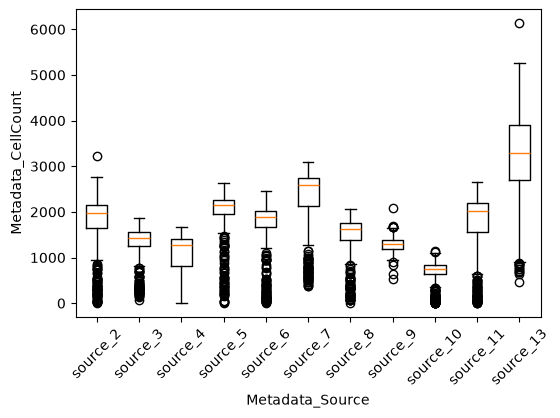

In [4]:
ax = mt.pl.cell_counts(adata, groupby="Metadata_Source")

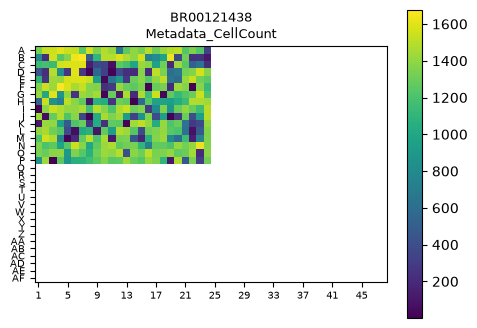

In [5]:
ax = mt.pl.plate(adata, color="Metadata_CellCount", plate="BR00121438")

Wells with a fraction of the plate's cells are why a distance from the controls alone ranks cell death as the
strongest phenotype on this plate; {func}`~mantispy.tl.cytotoxicity` flags them.